## ML training for paper

### Imports

In [44]:
from datetime import datetime
import pandas
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import LeaveOneGroupOut, cross_validate
from xgboost import XGBRegressor


### Split into train, test, and validation datasets

In [3]:
# Read in the dataset
total_dataset = pandas.read_parquet(
    "./data/total_dataset.parquet", engine="pyarrow"
)

In [4]:
# Initialize empty dataframes for test and validation sets
test_set = pandas.DataFrame()
test_set_indices = []
validation_set = pandas.DataFrame()
validation_set_indices = []

for name, group in total_dataset.groupby("region_code"):
    # Keep track of the last available year for each region
    max_year = group["local_year"].max()

    # Select the test set by selecting the last year
    group_test_set = group[group["local_year"] == max_year].copy()
    test_set_indices.append(group_test_set.index)
    test_set = pandas.concat([test_set, group_test_set], ignore_index=True)

    # Select the validation set by selecting the second last year
    group_val_set = group[group["local_year"] == max_year - 1].copy()
    validation_set_indices.append(group_val_set.index)
    validation_set = pandas.concat(
        [validation_set, group_val_set], ignore_index=True
    )

print("Test set size:", round((len(test_set) / len(total_dataset))*100,2), "% of total dataset")
print("Validation set size:", round((len(validation_set) / len(total_dataset))*100,2), "% of total dataset")

Test set size: 8.91 % of total dataset
Validation set size: 9.84 % of total dataset


In [5]:
# Obtain the indicies of the test and validation sets
all_test_set_indices = [
    index for list_indicies in test_set_indices for index in list_indicies
]
all_val_set_indices = [
    index
    for list_indicies in validation_set_indices
    for index in list_indicies
]

In [7]:
# Drop test and validation sets from the combined dataset
print("Size before:",len(total_dataset))
train_set = total_dataset.drop(index=all_test_set_indices).copy()
train_set = train_set.drop(index=all_val_set_indices)
print("After removing test and val sets:",len(train_set))

Size before: 7435129
After removing test and val sets: 6041222


In [105]:
train_set.head()

,time_utc,local_hour,is_weekend,local_month,local_year,year_temp_top1,year_temp_top3,monthly_temp_avg_top1,monthly_temp_avg_rank_top1,year_temp_avg_top1,year_temp_percentile_5,year_temp_percentile_95,region_code,load_mw,load_mw_percentage
0,2000-01-01 03:00:00,1,1,1,2000,298.412811,298.300842,298.983521,8.0,299.380615,296.219357,304.797337,BR_N,2373.7,0.000109
1,2000-01-01 03:00:00,1,1,1,2000,293.334686,293.494202,295.275848,1.0,292.583405,284.913759,300.310954,BR_SE,21183.0,0.000094
2,2000-01-01 03:00:00,1,1,1,2000,299.080780,298.188843,299.841431,6.0,299.724396,297.591458,302.318542,BR_NE,5340.2,0.000104
3,2000-01-01 03:00:00,1,1,1,2000,292.053436,293.098358,293.658997,1.0,290.223969,281.118460,298.741829,BR_S,5777.0,0.000098
4,2000-01-01 04:00:00,2,1,1,2000,298.599792,298.074615,298.983521,8.0,299.380615,296.219357,304.797337,BR_N,2331.6,0.000107


### Data preparation

In [368]:
def prepare_data(dataset: pandas.DataFrame):
    """
    Process the dataset into splits to be used in training the model.

    Returns
    -------
    features : pandas.DataFrame
        Features for the model.
    target : pandas.Series
        Column with the target variable.
    groups : pandas.Series
        Column containing the region codes
    """
    features = dataset[
        [
            "local_hour",
            "is_weekend",
            "local_month",
            "year_temp_top1",
            "year_temp_top3",
            "monthly_temp_avg_top1",
            "monthly_temp_avg_rank_top1",
            "year_temp_avg_top1",
            "year_temp_percentile_5",
            "year_temp_percentile_95",
            #"year_electricity_demand_per_capita_mwh",
            #"year_gdp",
        ]
    ].copy(deep=True).reset_index(drop=True)

    categorical_features = [
        "local_hour",
        "is_weekend",
        "local_month",
        "monthly_temp_avg_rank_top1",
    ]

    for cat_feature in categorical_features:
        features[cat_feature] = features[cat_feature].astype("category")

    target = dataset["load_mw_percentage"].copy(deep=True).reset_index(drop=True)
    groups = dataset["region_code"].copy(deep=True).reset_index(drop=True)

    return features, target, groups

In [369]:
# Generate the train, validation, and test datasets
train_features, train_target, train_groups = prepare_data(train_set)
val_features, val_target, val_groups = prepare_data(validation_set)
test_features, test_target, test_groups = prepare_data(test_set)

### Training

In [344]:
# Initialize the XGBoost regressor
xgb_model = XGBRegressor(
    random_state=42,
    enable_categorical=True,
    eval_metric=mean_absolute_percentage_error,
)

In [345]:
# Train the model
xgb_model.fit(
    train_features, train_target, eval_set=[(val_features, val_target)]
)

[0]	validation_0-rmse:0.00002	validation_0-mean_absolute_percentage_error:0.14745
[1]	validation_0-rmse:0.00002	validation_0-mean_absolute_percentage_error:0.13202
[2]	validation_0-rmse:0.00002	validation_0-mean_absolute_percentage_error:0.12205
[3]	validation_0-rmse:0.00002	validation_0-mean_absolute_percentage_error:0.11559
[4]	validation_0-rmse:0.00002	validation_0-mean_absolute_percentage_error:0.11113
[5]	validation_0-rmse:0.00002	validation_0-mean_absolute_percentage_error:0.10805
[6]	validation_0-rmse:0.00002	validation_0-mean_absolute_percentage_error:0.10610
[7]	validation_0-rmse:0.00002	validation_0-mean_absolute_percentage_error:0.10523
[8]	validation_0-rmse:0.00002	validation_0-mean_absolute_percentage_error:0.10434
[9]	validation_0-rmse:0.00002	validation_0-mean_absolute_percentage_error:0.10283
[10]	validation_0-rmse:0.00002	validation_0-mean_absolute_percentage_error:0.10207
[11]	validation_0-rmse:0.00002	validation_0-mean_absolute_percentage_error:0.10198
[12]	validatio

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True,
             eval_metric=<function mean_absolute_percentage_error at 0x716433cc87c0>,
             feature_types=None, feature_weights=None, gamma=None,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, ...)

In [347]:
# Store the trained model
xgb_model.save_model("./data/xgboost_model"+datetime.now().strftime("%Y_%m_%d_%H%M")+".bin")

/workspaces/demandcast/models/xgboost/.venv/lib/python3.12/site-packages/xgboost/sklearn.py:1028: UserWarning: [10:53:34] WARNING: /workspace/src/c_api/c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  self.get_booster().save_model(fname)


In [373]:
print(xgb_model.feature_names_in_)
print(xgb_model.feature_importances_)

['local_hour' 'is_weekend' 'local_month' 'year_temp_top1' 'year_temp_top3'
 'monthly_temp_avg_top1' 'monthly_temp_avg_rank_top1' 'year_temp_avg_top1'
 'year_temp_percentile_5' 'year_temp_percentile_95']
[0.30026576 0.2280793  0.05197475 0.04162017 0.13244206 0.09074059
 0.0420028  0.03902736 0.04379981 0.03004745]


### Prediction on test set

In [362]:
def calculate_test_error_metric(
    error_metric, error_metric_name: str, current_predictions, current_target, current_groups, message: str = ""
) -> pandas.DataFrame:
    """
    Calcuate the mean absolute percentage error for the test set
    Saves the results to a parquet and CSV file.

    Returns
    -------
    pandas.DataFrame
        A DataFrame with the region codes, years,
        and mean absolute percentage errors for the test set.
    """
    list_test_metric_values = []
    for name, group in current_groups.groupby("region_code"):
        current_metric = error_metric(
            current_predictions[group.index], current_target.iloc[group.index]
        )

        list_test_metric_values.append([name, current_metric])

    df_validation_metric_values = pandas.DataFrame(
        list_test_metric_values, columns=["region_code", error_metric_name]
    )

    df_validation_metric_values.to_parquet(
        "data/"+datetime.now().strftime("%Y_%m_%d_%H%M")+"_" + error_metric_name + "_values" + message + ".parquet", engine="pyarrow"
    )
    df_validation_metric_values.to_csv("data/"+datetime.now().strftime("%Y_%m_%d_%H%M")+"_"+error_metric_name+"_values" + message + ".csv")

    return df_validation_metric_values

In [364]:
# Predict on test set and calculate MAPE
test_predictions = xgb_model.predict(test_features)
calculate_test_error_metric(mean_absolute_percentage_error, "MAPE", test_predictions, test_target, test_groups , "_test")

,region_code,MAPE
0,AL,0.153867
1,AT,0.084286
2,BA,0.165569
3,BE,0.050524
4,BG,0.101998
...,...,...
83,US_SW,0.118146
84,US_TEN,0.079264
85,US_TEX,0.069438
86,XK,0.095917


In [366]:
# Predict on validation set and calculate MAPE
val_predictions = xgb_model.predict(val_features)
calculate_test_error_metric(mean_absolute_percentage_error, "MAPE", val_predictions, val_target, val_groups, "_val")

,region_code,MAPE
0,AL,0.439747
1,AT,0.081526
2,BA,0.127264
3,BE,0.054569
4,BG,0.110643
...,...,...
80,US_SW,0.110329
81,US_TEN,0.079378
82,US_TEX,0.080360
83,XK,0.174214


In [367]:
# Predict on training set and calculate MAPE
train_predictions = xgb_model.predict(train_features)
calculate_test_error_metric(mean_absolute_percentage_error, "MAPE", train_predictions, train_target, train_groups, "_train")

,region_code,MAPE
0,AL,0.207763
1,AT,0.078709
2,BA,0.109309
3,BE,0.053912
4,BG,0.078319
...,...,...
80,US_SW,0.113345
81,US_TEN,0.084725
82,US_TEX,0.076402
83,XK,0.178935


### Cross-validation

In [47]:
# Read in the dataset
total_dataset = pandas.read_parquet(
    "./data/total_dataset.parquet", engine="pyarrow"
)

In [48]:
cv_features, cv_target, cv_groups = prepare_data(total_dataset)

cv_xgb_model = XGBRegressor(
    random_state=42,
    enable_categorical=True,
    eval_metric=mean_absolute_percentage_error,
)

In [49]:
# Perform cross-validation
cv_results = cross_validate(
    cv_xgb_model,
    cv_features,
    cv_target,
    groups=cv_groups,
    cv=LeaveOneGroupOut(),
    scoring=["neg_mean_absolute_percentage_error"],
    return_train_score=True,
    return_indices=True,
    return_estimator=True,
    n_jobs=1,
)

In [50]:
cv_results["indices_train"] = cv_results["indices"]["train"]
cv_results["indices_test"] = cv_results["indices"]["test"]

cv_results_filtered = {k: v for k, v in cv_results.items() if k != "indices"}

df_cv_results = pandas.DataFrame(cv_results_filtered)

df_cv_results["test_MAPE"] = -df_cv_results[
    "test_neg_mean_absolute_percentage_error"
]
df_cv_results["train_MAPE"] = -df_cv_results[
    "train_neg_mean_absolute_percentage_error"
]

In [51]:
df_cv_results.head()

,fit_time,score_time,estimator,test_neg_mean_absolute_percentage_error,train_neg_mean_absolute_percentage_error,indices_train,indices_test,test_MAPE,train_MAPE
0,14.971514,0.014148,"XGBRegressor(base_score=None, booster=None, ca...",-0.302680,-236283.939005,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[1401940, 1402785, 1403389, 1403448, 1403512, ...",0.302680,236283.939005
1,12.504968,0.040246,"XGBRegressor(base_score=None, booster=None, ca...",-0.084845,-236386.884384,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[1380211, 1380234, 1380256, 1380278, 1380295, ...",0.084845,236386.884384
2,11.770723,0.021906,"XGBRegressor(base_score=None, booster=None, ca...",-0.145751,-236002.303045,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[2424366, 2424424, 2424498, 2424557, 2424638, ...",0.145751,236002.303045
3,11.620057,0.037691,"XGBRegressor(base_score=None, booster=None, ca...",-0.057207,-235243.111755,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[1377306, 1377327, 1377349, 1377356, 1377376, ...",0.057207,235243.111755
4,12.244521,0.022771,"XGBRegressor(base_score=None, booster=None, ca...",-0.088352,-235262.105183,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[1397647, 1397732, 1397775, 1397801, 1397825, ...",0.088352,235262.105183


In [52]:
list_test_group_id = []
for test_indices in cv_results["indices"]["test"]:
    list_test_group_id.append(cv_groups.iloc[test_indices[0]])

df_cv_results["group_id"] = list_test_group_id

In [53]:
df_cv_output = df_cv_results[
    ["group_id", "train_MAPE", "test_MAPE", "fit_time", "score_time"]
]

In [54]:
df_cv_output.to_parquet("./data/cv_results"+datetime.now().strftime("%Y_%m_%d_%H%M")+".parquet", engine="pyarrow")
df_cv_output.to_csv("./data/cv_results_"+datetime.now().strftime("%Y_%m_%d_%H%M")+".csv")

### Synthetic data

In [75]:
# Load data and model
total_dataset = pandas.read_parquet(
    "./data/total_dataset.parquet", engine="pyarrow"
)
trained_xgb_model = XGBRegressor()
trained_xgb_model.load_model("./data/xgboost_model.bin")

In [77]:
# Extract features used in model
input_features_columns = trained_xgb_model.feature_names_in_
input_features = total_dataset[input_features_columns]

In [78]:
predictions = trained_xgb_model.predict(input_features)

In [81]:
synthetic_dataset = total_dataset.drop(columns=input_features_columns)
synthetic_dataset["predictions"] = predictions
synthetic_dataset = synthetic_dataset.drop(
    columns=[
        "local_year",
        "load_mw",
    ]
)
synthetic_dataset.head()

,time_utc,region_code,load_mw_percentage,predictions
0,2000-01-01 03:00:00,BR_N,0.000109,0.000109
1,2000-01-01 03:00:00,BR_SE,0.000094,0.000102
2,2000-01-01 03:00:00,BR_NE,0.000104,0.000112
3,2000-01-01 03:00:00,BR_S,0.000098,0.000102
4,2000-01-01 04:00:00,BR_N,0.000107,0.000109


In [82]:
synthetic_dataset.to_parquet(
    "./data/synthetic_dataset.parquet", engine="pyarrow"
)

## Visualizations

### Visualize train, test, and validation sets split

In [306]:
import matplotlib.pyplot as plt

# Get the years from the respective datasets
train_set_years = pandas.DataFrame(train_set.groupby("region_code")["local_year"].unique())
validation_set_years = pandas.DataFrame(validation_set.groupby("region_code")["local_year"].unique())
test_set_years = pandas.DataFrame(test_set.groupby("region_code")["local_year"].unique())

years_per_region = pandas.merge(train_set_years, validation_set_years, on="region_code", how="outer", suffixes=["_train","_val"])
years_per_region = pandas.merge(years_per_region, test_set_years, on="region_code", how="outer")
years_per_region = years_per_region.reset_index()

years_per_region.columns = ["region_code", "train_years", "val_years", "test_years"]


In [307]:
# Calculate total data length across all splits
years_per_region['total_data_length'] = years_per_region.apply(
    lambda row: (
        (len(row['train_years']) if isinstance(row['train_years'], np.ndarray) else 0) +
        (len(row['val_years']) if isinstance(row['val_years'], np.ndarray) else 0) +
        (len(row['test_years']) if isinstance(row['test_years'], np.ndarray) else 0)
    ),
    axis=1
)
# Sort by total data length
years_per_region = years_per_region.sort_values(by='total_data_length', ascending=True)

# Drop the helper column
years_per_region = years_per_region.drop(columns=['total_data_length'])

# Reset the index
years_per_region = years_per_region.reset_index(drop=True)

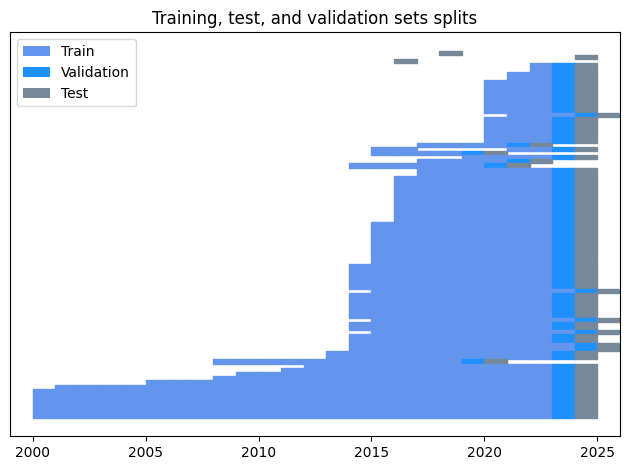

In [374]:

fig, ax = plt.subplots()
list_labels = []
y_min_counter = 0
line_thickness = 0.1


# Ensure the colors will correspond to the legend
train_color = "cornflowerblue"
val_color = "dodgerblue"
test_color = "lightslategray"

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=train_color, label='Train'),
    Patch(facecolor=val_color, label='Validation'),
    Patch(facecolor=test_color, label='Test')
]


for id, row in years_per_region.iterrows():
    
    if isinstance(row["train_years"], np.ndarray):
        ax.broken_barh([(int(year),1) for year in row["train_years"]], (y_min_counter, line_thickness), color=train_color)
    if isinstance(row["val_years"], np.ndarray):
        ax.broken_barh([(int(year),1) for year in row["val_years"]], (y_min_counter, line_thickness), color=val_color)
    if isinstance(row["test_years"], np.ndarray):
        ax.broken_barh([(int(year),1) for year in row["test_years"]], (y_min_counter, line_thickness), color=test_color)

    y_min_counter += 0.1

ax.set_xlim(1999, 2026)
ax.set_yticks(range(len(list_labels)),
              labels=list_labels)
ax.invert_yaxis()
ax.set_title("Training, test, and validation sets splits")
# Add legend with custom handles
ax.legend(handles=legend_elements, loc="upper left")
plt.tight_layout()
plt.savefig("train_val_test_split.jpg", dpi=300)

plt.show()